In [8]:
# Fetch

import os
import sys 
from pathlib import Path 
import pandas as pd

wd = Path(os.getcwd())
root = wd.parent
if str(root).split("\\")[-1] == "TSDP":
    os.chdir(root)
else:
    print("Wrong root directory")

gamelogs_raw = pd.read_excel("datafiles/gamelogs_raw.xlsx")
gamelogs = gamelogs_raw.copy()

Wrong root directory
   Wk  Day        Date           Time            Home   xG Score  xG.1  \
0   1  Fri  2022-08-05  20:00 (21:00)  Crystal Palace  1.2   0–2   1.0   
1   1  Sat  2022-08-06  12:30 (13:30)          Fulham  1.2   2–2   1.2   
2   1  Sat  2022-08-06  15:00 (16:00)   Newcastle Utd  1.7   2–0   0.3   
3   1  Sat  2022-08-06  15:00 (16:00)     Bournemouth  0.6   2–0   0.7   
4   1  Sat  2022-08-06  15:00 (16:00)    Leeds United  0.8   2–1   1.3   

              Away  Attendance             Venue         Referee  \
0          Arsenal     25286.0     Selhurst Park  Anthony Taylor   
1        Liverpool     22207.0    Craven Cottage     Andy Madley   
2  Nott'ham Forest     52245.0    St James' Park    Simon Hooper   
3      Aston Villa     11013.0  Vitality Stadium    Peter Bankes   
4           Wolves     36347.0       Elland Road    Robert Jones   

   Match Report Notes Country     Season  
0  Match Report   NaN     ENG  2022-2023  
1  Match Report   NaN     ENG  2022-202

In [16]:
gamelogs = gamelogs[pd.notna(gamelogs['xG'])]

print(gamelogs.head(5))
print('')

   Wk  Day        Date           Time            Home   xG Score  xG.1  \
0   1  Fri  2022-08-05  20:00 (21:00)  Crystal Palace  1.2   0–2   1.0   
1   1  Sat  2022-08-06  12:30 (13:30)          Fulham  1.2   2–2   1.2   
2   1  Sat  2022-08-06  15:00 (16:00)   Newcastle Utd  1.7   2–0   0.3   
3   1  Sat  2022-08-06  15:00 (16:00)     Bournemouth  0.6   2–0   0.7   
4   1  Sat  2022-08-06  15:00 (16:00)    Leeds United  0.8   2–1   1.3   

              Away  Attendance             Venue         Referee  \
0          Arsenal     25286.0     Selhurst Park  Anthony Taylor   
1        Liverpool     22207.0    Craven Cottage     Andy Madley   
2  Nott'ham Forest     52245.0    St James' Park    Simon Hooper   
3      Aston Villa     11013.0  Vitality Stadium    Peter Bankes   
4           Wolves     36347.0       Elland Road    Robert Jones   

   Match Report Notes Country     Season  
0  Match Report   NaN     ENG  2022-2023  
1  Match Report   NaN     ENG  2022-2023  
2  Match Report  

In [18]:
import pandas as pd

# Feltételezzük, hogy a dataframe neve: gamelogs
df = gamelogs.copy()

# Date biztosan datetime legyen
df["Date"] = pd.to_datetime(df["Date"])

# --- 1. HOME csapat nézet ---
home_df = df[[
    "Date", "Season", "Home", "Away", "xG", "xG.1", "Score"
]].copy()

home_df.rename(columns={
    "Home": "team",
    "Away": "opponent",
    "xG": "xG_for",
    "xG.1": "xG_against"
}, inplace=True)

home_df["home_away"] = "H"

# --- 2. AWAY csapat nézet ---
away_df = df[[
    "Date", "Season", "Home", "Away", "xG", "xG.1", "Score"
]].copy()

away_df.rename(columns={
    "Away": "team",
    "Home": "opponent",
    "xG.1": "xG_for",
    "xG": "xG_against"
}, inplace=True)

away_df["home_away"] = "A"

# --- 3. Long format összeillesztése ---
team_games = pd.concat([home_df, away_df], ignore_index=True)

# --- 4. Rendezés Date szerint, csapatonként ---
team_games = team_games.sort_values(["team", "Date"])

# --- 5. Csapatonkénti meccsszámozás ---
team_games["match_idx"] = (
    team_games
    .groupby("team")
    .cumcount() + 1
)

# Index opcionálisan reset
team_games.reset_index(drop=True, inplace=True)
#team_games

,Date,Season,team,opponent,xG_for,xG_against,Score,home_away,match_idx
0,2023-08-14,2023-2024,Alavés,Cádiz,0.3,0.7,1–0,A,1
1,2023-08-21,2023-2024,Alavés,Sevilla,1.8,0.6,4–3,H,2
2,2023-08-28,2023-2024,Alavés,Getafe,0.7,2.2,1–0,A,3
3,2023-09-02,2023-2024,Alavés,Valencia,1.3,0.8,1–0,H,4
4,2023-09-15,2023-2024,Alavés,Rayo Vallecano,0.7,2.6,2–0,A,5
...,...,...,...,...,...,...,...,...,...
8671,2025-04-26,2024-2025,Wolves,Leicester City,2.0,1.1,3–0,H,110
8672,2025-05-02,2024-2025,Wolves,Manchester City,0.4,0.7,1–0,A,111
8673,2025-05-10,2024-2025,Wolves,Brighton,0.9,1.6,0–2,H,112
8674,2025-05-20,2024-2025,Wolves,Crystal Palace,1.4,1.7,4–2,A,113


In [19]:
arsenal = team_games[team_games["team"] == "Arsenal"]
arsenal.set_index("match_idx")[["xG_for", "xG_against"]]


,xG_for,xG_against
match_idx,,
1,1.0,1.2
2,2.7,0.5
3,1.3,0.3
4,2.6,0.8
5,2.4,0.4
...,...,...
110,1.2,1.7
111,1.4,0.9
112,2.6,2.4


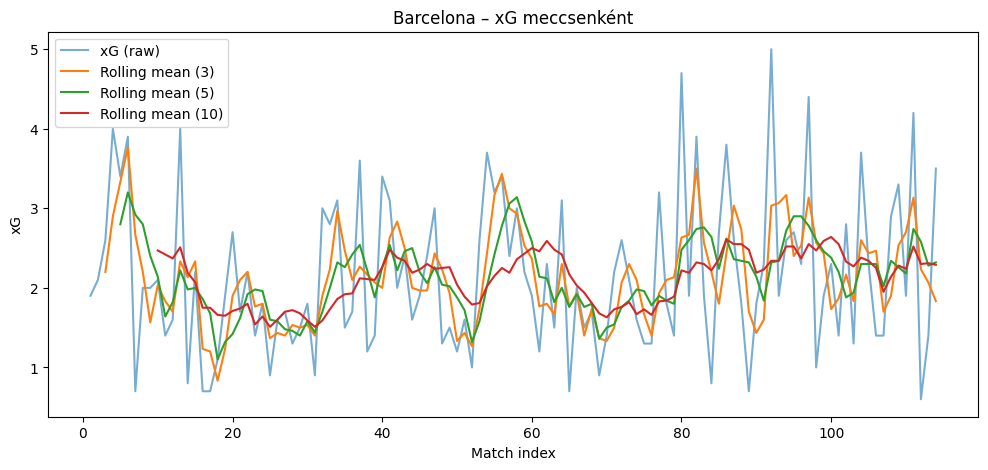

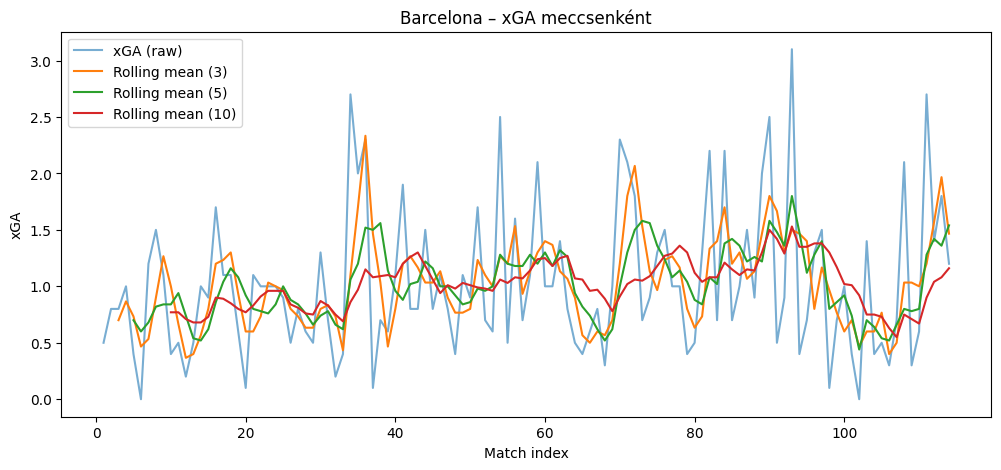

                mean       std        cv
xG_for      2.145614  0.973647  0.453785
xG_against  1.024561  0.647604  0.632080


<Figure size 1000x400 with 0 Axes>

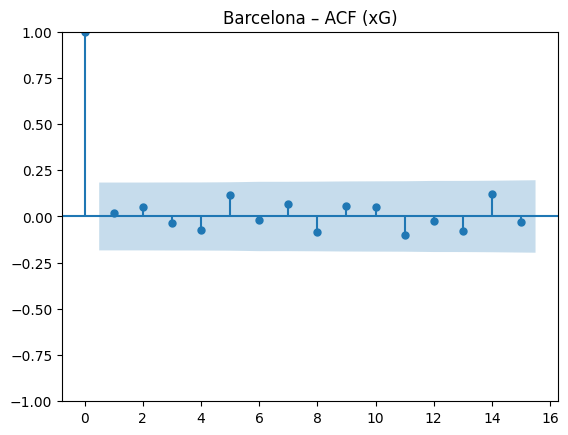

<Figure size 1000x400 with 0 Axes>

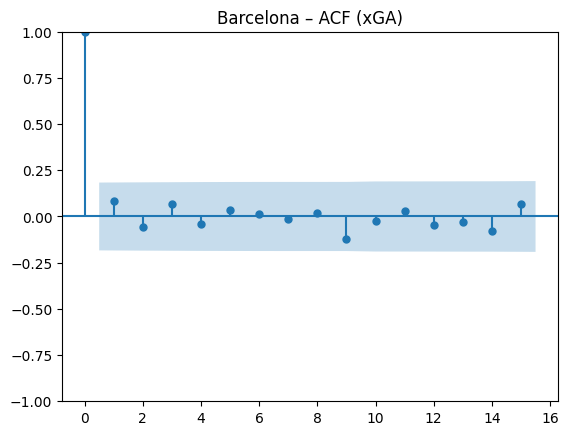

<Figure size 1000x400 with 0 Axes>

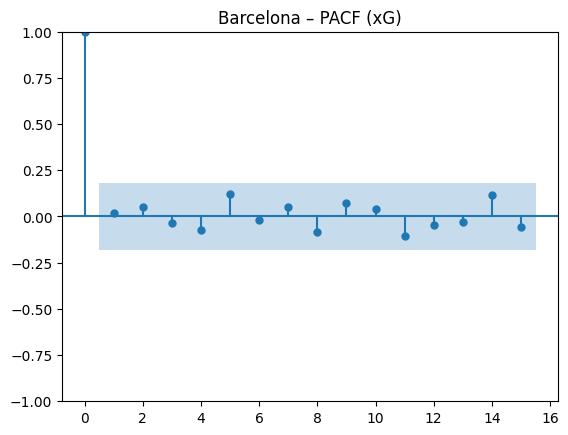

<Figure size 1000x400 with 0 Axes>

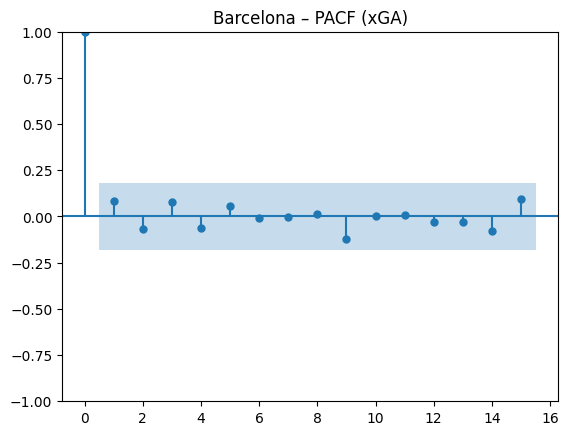

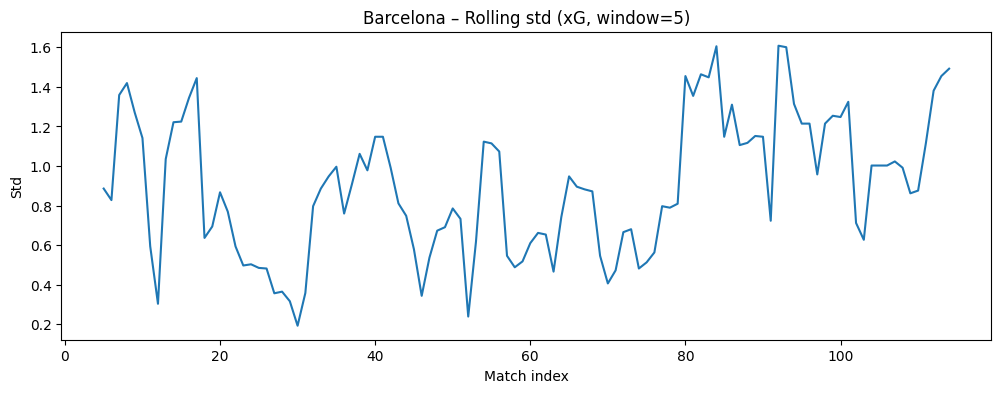

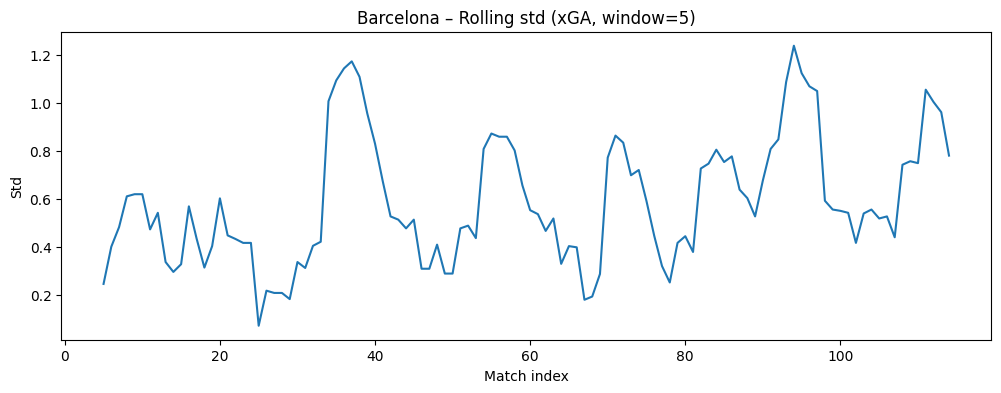

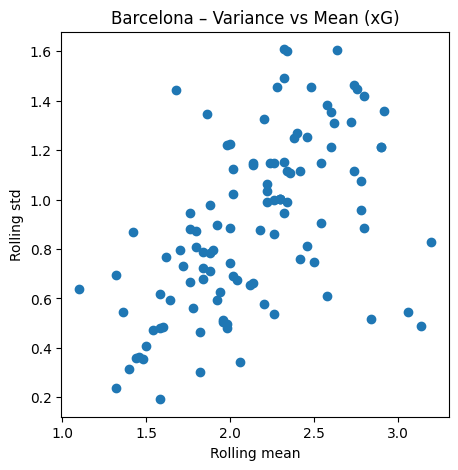

In [30]:
TEAM = "Barcelona"

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

df_team = (
    team_games
    .loc[team_games["team"] == TEAM]
    .sort_values("match_idx")
    .set_index("match_idx")
)

window_sizes = [3, 5, 10]

plt.figure(figsize=(12, 5))
plt.plot(df_team.index, df_team["xG_for"], label="xG (raw)", alpha=0.6)

for w in window_sizes:
    plt.plot(
        df_team.index,
        df_team["xG_for"].rolling(w).mean(),
        label=f"Rolling mean ({w})"
    )

plt.title(f"{TEAM} – xG meccsenként")
plt.xlabel("Match index")
plt.ylabel("xG")
plt.legend()
plt.show()

plt.figure(figsize=(12, 5))
plt.plot(df_team.index, df_team["xG_against"], label="xGA (raw)", alpha=0.6)

for w in window_sizes:
    plt.plot(
        df_team.index,
        df_team["xG_against"].rolling(w).mean(),
        label=f"Rolling mean ({w})"
    )

plt.title(f"{TEAM} – xGA meccsenként")
plt.xlabel("Match index")
plt.ylabel("xGA")
plt.legend()
plt.show()

summary_stats = pd.DataFrame({
    "mean": df_team[["xG_for", "xG_against"]].mean(),
    "std": df_team[["xG_for", "xG_against"]].std(),
    "cv": (
        df_team[["xG_for", "xG_against"]].std()
        / df_team[["xG_for", "xG_against"]].mean()
    )
})

print(summary_stats)

plt.figure(figsize=(10, 4))
plot_acf(df_team["xG_for"], lags=15)
plt.title(f"{TEAM} – ACF (xG)")
plt.show()

plt.figure(figsize=(10, 4))
plot_acf(df_team["xG_against"], lags=15)
plt.title(f"{TEAM} – ACF (xGA)")
plt.show()

plt.figure(figsize=(10, 4))
plot_pacf(df_team["xG_for"], lags=15, method="ywm")
plt.title(f"{TEAM} – PACF (xG)")
plt.show()

plt.figure(figsize=(10, 4))
plot_pacf(df_team["xG_against"], lags=15, method="ywm")
plt.title(f"{TEAM} – PACF (xGA)")
plt.show()

rolling_std = df_team["xG_for"].rolling(5).std()

plt.figure(figsize=(12, 4))
plt.plot(df_team.index, rolling_std)
plt.title(f"{TEAM} – Rolling std (xG, window=5)")
plt.xlabel("Match index")
plt.ylabel("Std")
plt.show()

rolling_std_xga = df_team["xG_against"].rolling(5).std()

plt.figure(figsize=(12, 4))
plt.plot(df_team.index, rolling_std_xga)
plt.title(f"{TEAM} – Rolling std (xGA, window=5)")
plt.xlabel("Match index")
plt.ylabel("Std")
plt.show()

plt.figure(figsize=(5, 5))
plt.scatter(
    df_team["xG_for"].rolling(5).mean(),
    df_team["xG_for"].rolling(5).std()
)
plt.xlabel("Rolling mean")
plt.ylabel("Rolling std")
plt.title(f"{TEAM} – Variance vs Mean (xG)")
plt.show()


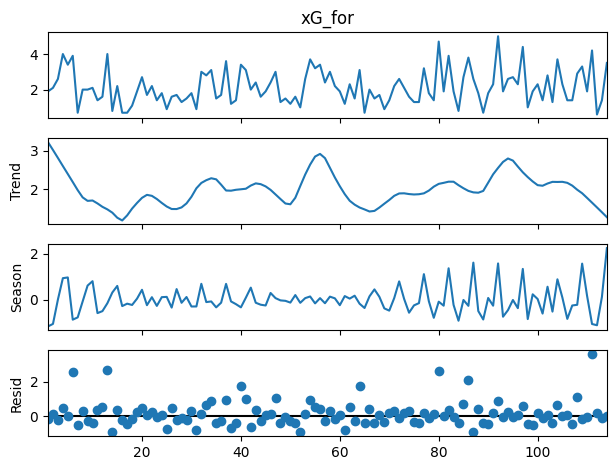

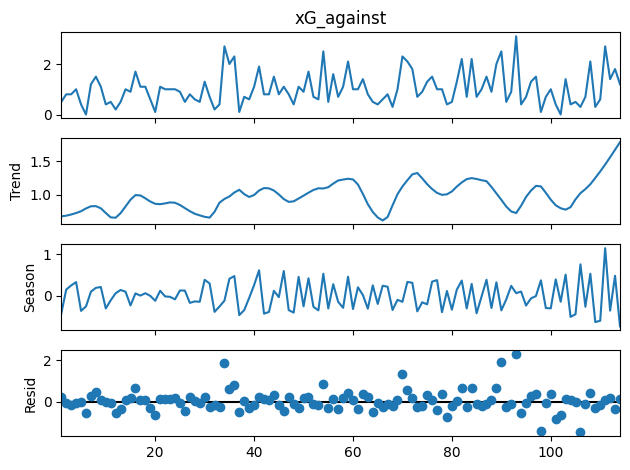

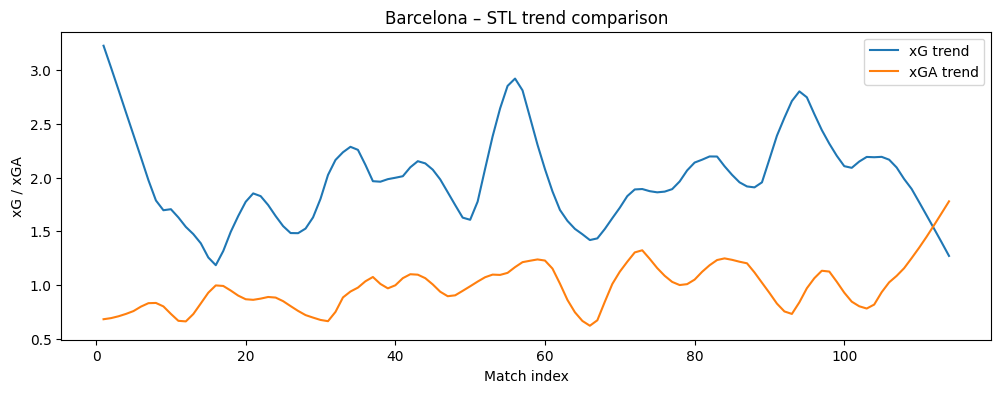

           xG_resid_std  xGA_resid_std
Barcelona       0.74685       0.516222


In [33]:
# STL dekompozíció

from statsmodels.tsa.seasonal import STL

xg_series = df_team["xG_for"]

stl_xg = STL(
    xg_series,
    period=5,
    robust=True
)

res_xg = stl_xg.fit()
res_xg.plot()
#plt.suptitle(f"{TEAM} – STL decomposition (xG)", fontsize=14)
plt.show()

xga_series = df_team["xG_against"]

stl_xga = STL(
    xga_series,
    period=5,
    robust=True
)

res_xga = stl_xga.fit()
res_xga.plot()
#plt.suptitle(f"{TEAM} – STL decomposition (xGA)", fontsize=14)
plt.show()

plt.figure(figsize=(12, 4))
plt.plot(res_xg.trend, label="xG trend")
plt.plot(res_xga.trend, label="xGA trend")
plt.title(f"{TEAM} – STL trend comparison")
plt.xlabel("Match index")
plt.ylabel("xG / xGA")
plt.legend()
plt.show()

residual_stats = pd.DataFrame({
    "xG_resid_std": res_xg.resid.std(),
    "xGA_resid_std": res_xga.resid.std()
}, index=[TEAM])

print(residual_stats)



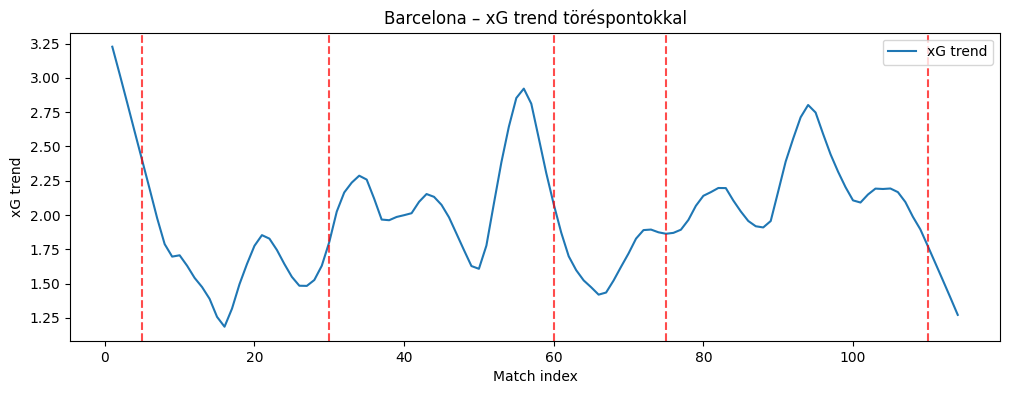

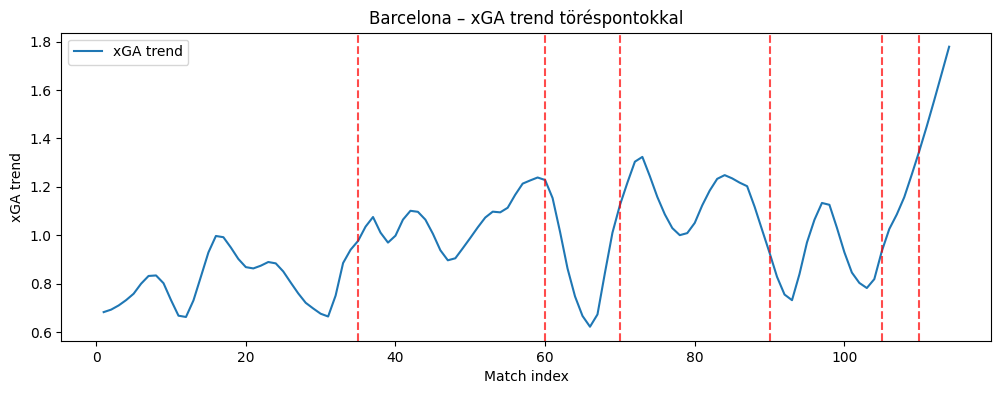

In [49]:
trend_xg = res_xg.trend.dropna()
trend_xga = res_xga.trend.dropna()

import numpy as np

trend_xg_arr = trend_xg.values
trend_xga_arr = trend_xga.values

import ruptures as rpt

algo_xg = rpt.Pelt(model="l2").fit(trend_xg_arr)
algo_xga = rpt.Pelt(model="l2").fit(trend_xga_arr)

breaks_xg = algo_xg.predict(pen=1.40)
breaks_xga = algo_xga.predict(pen=0.22)

plt.figure(figsize=(12, 4))
plt.plot(trend_xg.index, trend_xg, label="xG trend")

for bp in breaks_xg[:-1]:  # utolsót nem rajzoljuk (sor vége)
    plt.axvline(
        trend_xg.index[bp - 1],
        color="red",
        linestyle="--",
        alpha=0.7
    )

plt.title(f"{TEAM} – xG trend töréspontokkal")
plt.xlabel("Match index")
plt.ylabel("xG trend")
plt.legend()
plt.show()

plt.figure(figsize=(12, 4))
plt.plot(trend_xga.index, trend_xga, label="xGA trend")

for bp in breaks_xga[:-1]:
    plt.axvline(
        trend_xga.index[bp - 1],
        color="red",
        linestyle="--",
        alpha=0.7
    )

plt.title(f"{TEAM} – xGA trend töréspontokkal")
plt.xlabel("Match index")
plt.ylabel("xGA trend")
plt.legend()
plt.show()


In [60]:
# ARIMA

df_team = (
    team_games
    .loc[team_games["team"] == TEAM]
    .sort_values("match_idx")
    .set_index("match_idx")
)

from statsmodels.tsa.seasonal import STL

stl_xg = STL(df_team["xG_for"], period=5, robust=True).fit()
stl_xga = STL(df_team["xG_against"], period=5, robust=True).fit()

resid_xg = stl_xg.resid.dropna()
resid_xga = stl_xga.resid.dropna()


from statsmodels.tsa.stattools import adfuller

def adf_test(series, name):
    stat, pval, *_ = adfuller(series)
    print(f"{name}: ADF stat={stat:.3f}, p-value={pval:.4f}")

adf_test(resid_xg, "xG residual")
adf_test(resid_xga, "xGA residual")

from statsmodels.tsa.arima.model import ARIMA

model_xga = ARIMA(resid_xga, order=(0, 0, 0))
fit_xga = model_xga.fit()

print(fit_xga.summary())


xG residual: ADF stat=-6.866, p-value=0.0000
xGA residual: ADF stat=-10.563, p-value=0.0000
                               SARIMAX Results                                
Dep. Variable:                  resid   No. Observations:                  114
Model:                          ARIMA   Log Likelihood                 -85.878
Date:                Sat, 20 Dec 2025   AIC                            175.756
Time:                        21:04:28   BIC                            181.228
Sample:                             0   HQIC                           177.977
                                - 114                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0402      0.054      0.743      0.457      -0.066       0.146
sigma2         0.2641      0.020     12

c:\Users\Adam\AppData\Local\Programs\Python\Python313\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)
c:\Users\Adam\AppData\Local\Programs\Python\Python313\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)
c:\Users\Adam\AppData\Local\Programs\Python\Python313\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)


<Figure size 800x300 with 0 Axes>

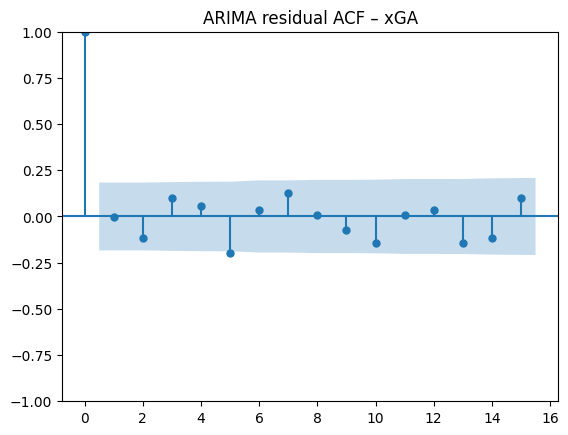

In [62]:
plt.figure(figsize=(8, 3))
plot_acf(fit_xga.resid, lags=15)
plt.title("ARIMA residual ACF – xGA")
plt.show()


c:\Users\Adam\AppData\Local\Programs\Python\Python313\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
c:\Users\Adam\AppData\Local\Programs\Python\Python313\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:837: FutureWarning: No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.
  return get_prediction_index(
c:\Users\Adam\AppData\Local\Programs\Python\Python313\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(


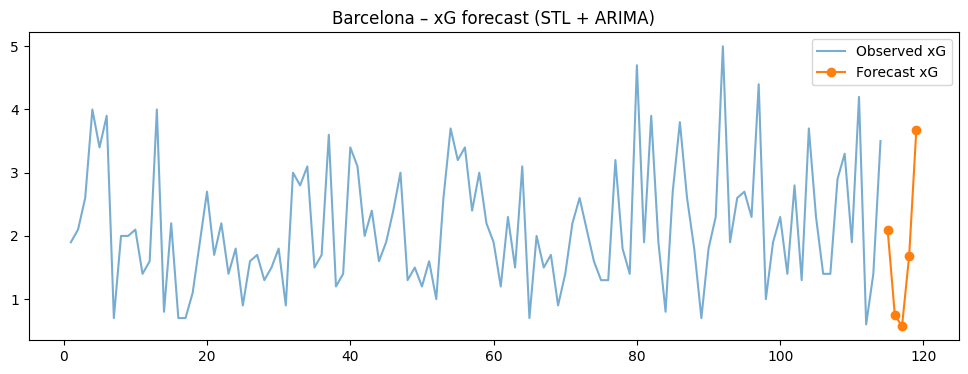

In [65]:
horizon = 5

fc_resid_xg = fit_xg.forecast(steps=horizon)
fc_resid_xga = fit_xga.forecast(steps=horizon)

last_trend_xg = stl_xg.trend.iloc[-horizon:]
last_season_xg = stl_xg.seasonal.iloc[-horizon:]

xg_forecast = last_trend_xg.values + last_season_xg.values + fc_resid_xg.values

plt.figure(figsize=(12, 4))
plt.plot(df_team.index, df_team["xG_for"], label="Observed xG", alpha=0.6)
plt.plot(
    range(df_team.index.max()+1, df_team.index.max()+1+horizon),
    xg_forecast,
    marker="o",
    label="Forecast xG"
)
plt.title(f"{TEAM} – xG forecast (STL + ARIMA)")
plt.legend()
plt.show()
